In [ ]:
class cfg:
    IMAGE_SIZE = 128

    # Data Augmentation
    BRIGHTNESS = (0.64, 1.37) # (MIN, MAX)
    CONTRAST   = (0.64, 1.37) # (MIN, MAX)

    # Train-Val Split
    TRAIN_VAL_SPLIT = 0.8 # 80% of all the samples are used for training, and the rest for validation

    # Model Training
    BATCH_SIZE = 8
    EPOCHS = 20
    LEARNING_RATE = 0.00008

In [ ]:
# Miscellaneous
from tqdm import tqdm
import random
import os
import time
# Turn off tensorflow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

# For Data Processing & ML Models
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import load_img
from PIL import Image, ImageEnhance
import cv2

# For Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
# Enable offline usage of plotly
import plotly.offline as pyo
pyo.init_notebook_mode(connected=True)

from IPython.display import clear_output
clear_output()

ModuleNotFoundError: No module named 'tqdm'

In [ ]:
tf.random.set_seed(100)
np.random.seed(100)

In [ ]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [ ]:
data_directories = {
    'train': 'train/',
    'val': 'val/',
    'test': 'test/'
}

def build_dataframe(data_dir):
    paths = []
    labels = []
    for label in sorted(os.listdir(data_dir)):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            continue
        for image in os.listdir(label_dir):
            paths.append(os.path.join(label_dir, image).replace('\\', '/'))
            labels.append(label)
    return pd.DataFrame({'path': paths, 'label': labels})

df_train = shuffle(build_dataframe(data_directories['train'])).reset_index(drop=True)
df_val = shuffle(build_dataframe(data_directories['val'])).reset_index(drop=True)
df_test = shuffle(build_dataframe(data_directories['test'])).reset_index(drop=True)
df = pd.concat([df_train, df_val, df_test], ignore_index=True)

pd.set_option('display.max_colwidth', None)
df



,path,label
0,train/COVID19/COVID19(374).jpg,COVID19
1,train/PNEUMONIA/person351_bacteria_1624.jpeg,PNEUMONIA
2,train/PNEUMONIA/person417_virus_850.jpeg,PNEUMONIA
3,train/PNEUMONIA/person1411_virus_2415.jpeg,PNEUMONIA
4,train/PNEUMONIA/person96_virus_179.jpeg,PNEUMONIA
...,...,...
7130,train/PNEUMONIA/person21_bacteria_73.jpeg,PNEUMONIA
7131,train/PNEUMONIA/person292_virus_598.jpeg,PNEUMONIA
7132,train/PNEUMONIA/person614_bacteria_2483.jpeg,PNEUMONIA
7133,train/TURBERCULOSIS/Tuberculosis-650.png,TUBERCULOSIS


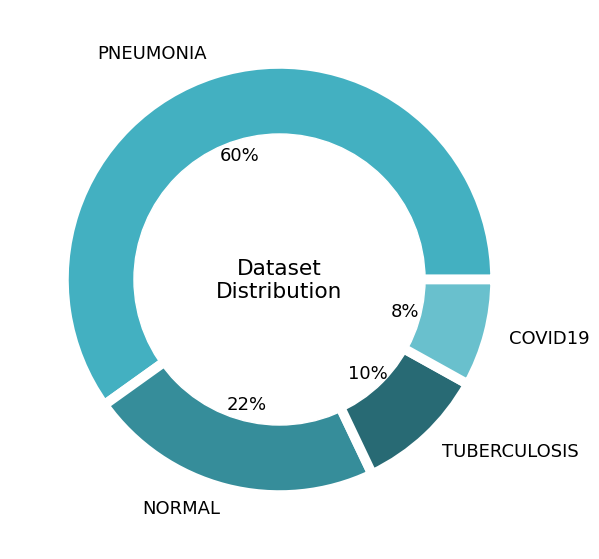

In [ ]:
plt.rcParams.update({'font.size': 13})

plt.figure(figsize=(7,7))

# plotting data on chart
plt.pie(list(df.label.value_counts()),
        labels=list(df.label.value_counts().index),
        colors=['#43b0c1', '#368d9a', '#286a74', '#69c0cd'],
        autopct='%.0f%%', wedgeprops = { 'linewidth' : 7, 'edgecolor' : 'white' })

my_circle=plt.Circle((0,0), 0.675, color='white')
p=plt.gcf()
p.gca().add_artist(my_circle)
plt.title('Dataset\nDistribution', x=0.5, y=0.45) 
plt.show()

In [ ]:
def augment_image(image):
    # Convert input image from numpy to PIL Image
    image = Image.fromarray(np.uint8(image)) 
    # Select brightness and contrast factors
    brightness_factor = random.uniform(cfg.BRIGHTNESS[0],cfg.BRIGHTNESS[1])
    contrast_factor = random.uniform(cfg.CONTRAST[0],cfg.CONTRAST[1])
    # Apply Transformations
    image = ImageEnhance.Brightness(image).enhance(brightness_factor)
    image = ImageEnhance.Contrast(image).enhance(contrast_factor)
    return image

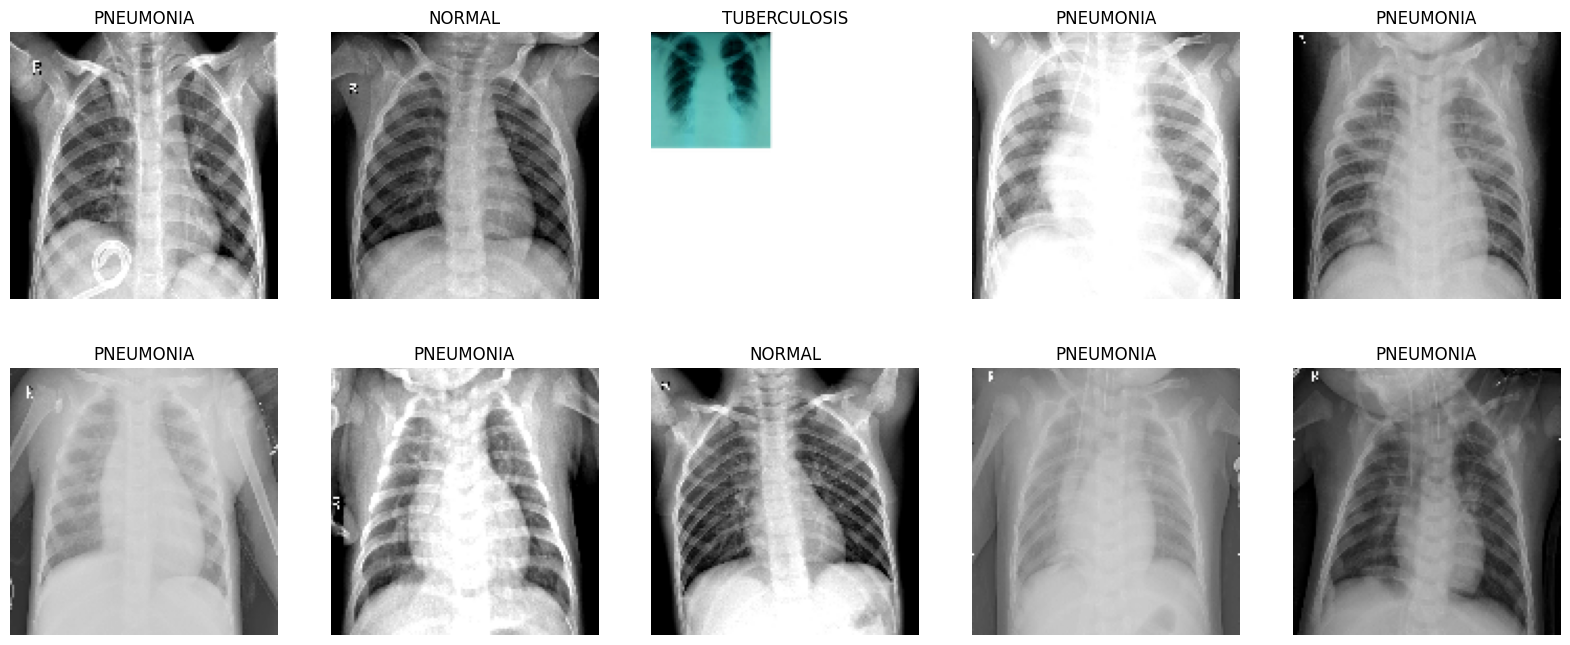

In [ ]:
def open_images(paths, augment=True):
    '''
    Given a list of paths to images, this function returns the images as arrays, and conditionally augments them
    '''
    images = []
    for path in paths:
        image = load_img(path, target_size=(cfg.IMAGE_SIZE,cfg.IMAGE_SIZE))
        if augment:
            image = augment_image(image)
        image = np.array(image)
        image = image/image.max()
        images.append(image)
    return np.array(images)

# Randomly select and plot a few images with augmentation
k = random.randint(0,5000)
image_paths = list(df.path[k:k+10])
labels = list(df.label[k:k+10])
images = open_images(image_paths, augment=True)

plt.rcParams.update({'font.size': 10})
fig = plt.figure(figsize=(20, 8))

for i in range(0, 10):
    fig.add_subplot(2, 5, i+1)
    plt.imshow(images[i])
    plt.axis('off')
    plt.title(labels[i])
plt.show()

In [ ]:
LABELS = ['COVID-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']
label_encoder = {label: idx for idx, label in enumerate(LABELS)}
label_decoder = {idx: label for label, idx in label_encoder.items()}



In [ ]:
print(f'Train samples: {len(df_train)}')
print(f'Validation samples: {len(df_val)}')
print(f'Test samples: {len(df_test)}')



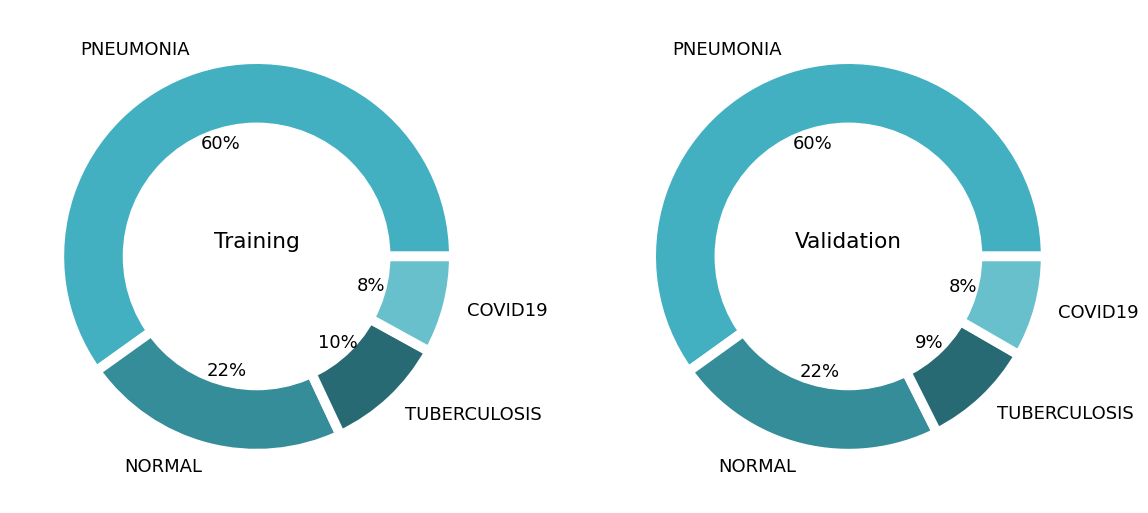

In [ ]:
plt.rcParams.update({'font.size': 13})
fig = plt.figure(figsize=(21, 7))

for subplot_index, (title, frame) in enumerate([
    ('Training', df_train),
    ('Validation', df_val),
    ('Test', df_test),
], start=1):
    fig.add_subplot(1, 3, subplot_index)
    plt.pie(list(frame.label.value_counts()),
            labels=list(frame.label.value_counts().index),
            colors=['#43b0c1', '#368d9a', '#286a74', '#69c0cd'],
            autopct='%.0f%%', wedgeprops={'linewidth': 7, 'edgecolor': 'white'})

    my_circle = plt.Circle((0, 0), 0.675, color='white')
    p = plt.gcf()
    p.gca().add_artist(my_circle)
    plt.axis('off')
    plt.title(title, x=0.5, y=0.5)

plt.show()



In [ ]:
def data_generator(df, batch_size=cfg.BATCH_SIZE, augment=True, epochs=cfg.EPOCHS):
    for e in range(epochs):
        for x in range(0,len(df), batch_size):
            image_paths = df.path[x:x+batch_size]
            images = open_images(image_paths, augment=augment)
            labels = df.label[x:x+batch_size]
            labels = [label_encoder[label] for label in labels]
            yield images, np.array(labels)

In [ ]:
# Creating generators for training and validation. You can change the parameters in the configuration section.
train_data_generator = data_generator(df_train, batch_size=cfg.BATCH_SIZE, augment=True, epochs=cfg.EPOCHS)
train_steps = len(df_train) // cfg.BATCH_SIZE

val_data_generator = data_generator(df_val, batch_size=cfg.BATCH_SIZE, augment=False, epochs=cfg.EPOCHS)
val_steps = len(df_val) // cfg.BATCH_SIZE



In [ ]:
model = models.Sequential(name='classifier')
model.add(layers.Input(shape=(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, 3), name='input'))
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', name='block1_conv1'))
model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', name='block1_conv2'))
model.add(layers.MaxPool2D(pool_size=(2,2), name='pool1'))
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='block2_conv1'))
model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', name='block2_conv2'))
model.add(layers.MaxPool2D(pool_size=(2,2), name='pool2'))
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='block3_conv1'))
model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', name='block3_conv2'))
model.add(layers.MaxPool2D(pool_size=(2,2), name='pool3'))
model.add(layers.Flatten(name='flatten'))
model.add(layers.Dropout(0.3, name='dropout1'))
model.add(layers.Dense(128, activation='relu', name='dense1'))
model.add(layers.Dense(4, activation='softmax', name='final'))

model.summary()

Model: "classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 128, 128, 32)      896       
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 32)      9248      
                                                                 
 pool1 (MaxPooling2D)        (None, 64, 64, 32)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 64)        18496     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 64)        36928     
                                                                 
 pool2 (MaxPooling2D)        (None, 32, 32, 64)        0         
                                                                 
 block3_conv1 (Conv2D)       (None, 32, 32, 128)       7

In [ ]:
model.compile(optimizer=optimizers.Adam(learning_rate=cfg.LEARNING_RATE),
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [ ]:
class_weights = (df_train.label.value_counts() / len(df_train)).to_dict()
class_weights = dict((label_encoder[key], value) for (key, value) in class_weights.items())
class_weights

{2: 0.5988086895585144,
 0: 0.22109320252277506,
 1: 0.10003503854239663,
 3: 0.08006306937631394}

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='final_model.hdf5',
    save_weights_only=False,
    monitor='val_accuracy',
    mode='max', verbose=1,
    save_best_only=True)

history = model.fit(train_data_generator, epochs=cfg.EPOCHS, steps_per_epoch=train_steps, class_weight=class_weights,
          validation_data=val_data_generator, validation_steps=val_steps, callbacks=[model_checkpoint_callback])

Epoch 1/20
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: 'arguments' object has no attribute 'posonlyargs'
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
713/713 [==============================] - ETA: 0s - loss: 0.1155 - accuracy: 0.7847WARNING:tensorflow:AutoGraph could not transform <function Model.make_test_function.<locals>.test_function at 0x000001CEFAAA5EA0> and will run it as-is.
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`

In [ ]:
test_data_generator = data_generator(df_test, batch_size=cfg.BATCH_SIZE, augment=False, epochs=1)
test_steps = len(df_test) // cfg.BATCH_SIZE

y_pred = []
y_true = []

for x, y in tqdm(test_data_generator, total=test_steps):
    pred = model.predict(x)
    pred = np.argmax(pred, axis=-1)
    for i in pred:
        y_pred.append(label_decoder[i])
    for i in y:
        y_true.append(label_decoder[i])
clear_output()
print(classification_report(y_true, y_pred, digits=4))



              precision    recall  f1-score   support

     COVID19     0.9091    0.9244    0.9167       119
      NORMAL     0.9562    0.8162    0.8807       321
   PNEUMONIA     0.9399    0.9871    0.9629       855
TUBERCULOSIS     0.9254    0.9394    0.9323       132

    accuracy                         0.9390      1427
   macro avg     0.9326    0.9168    0.9231      1427
weighted avg     0.9396    0.9390    0.9377      1427



1/1 [==============================] - 0s 46ms/step


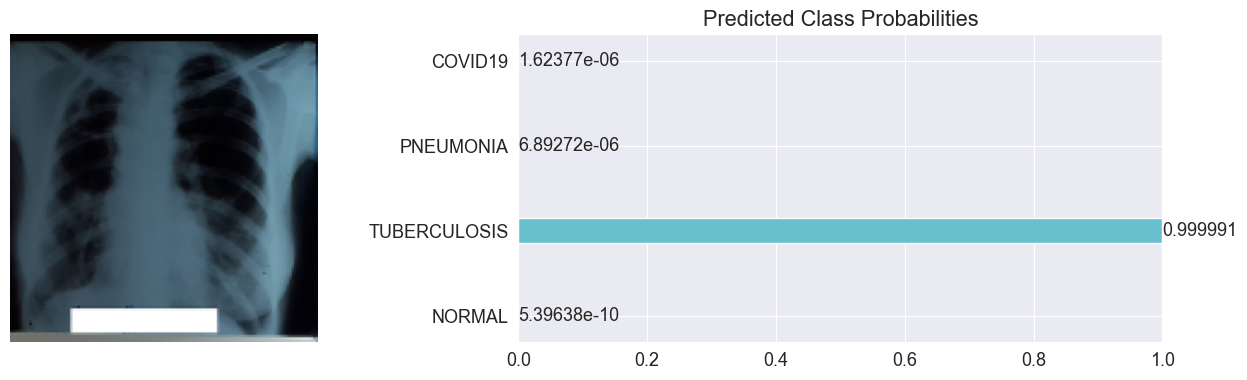

Actual   : TUBERCULOSIS
Predicted: TUBERCULOSIS
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 39ms/step


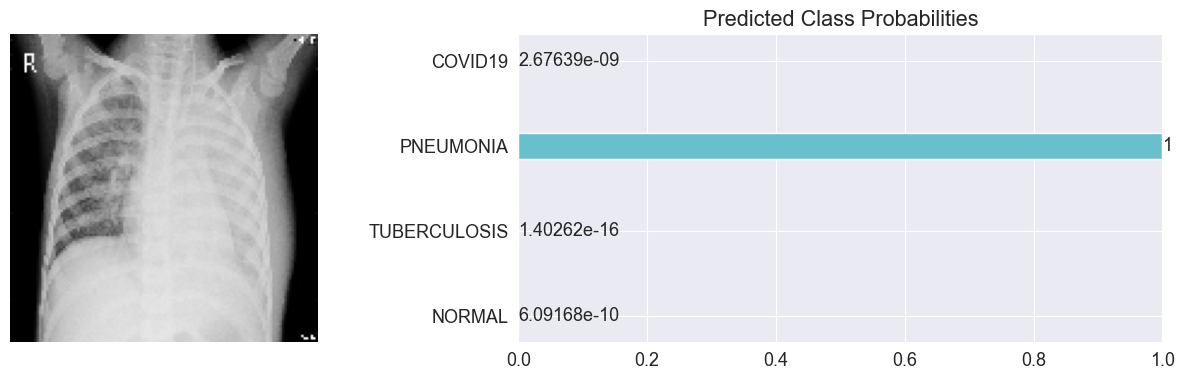

Actual   : PNEUMONIA
Predicted: PNEUMONIA
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 50ms/step


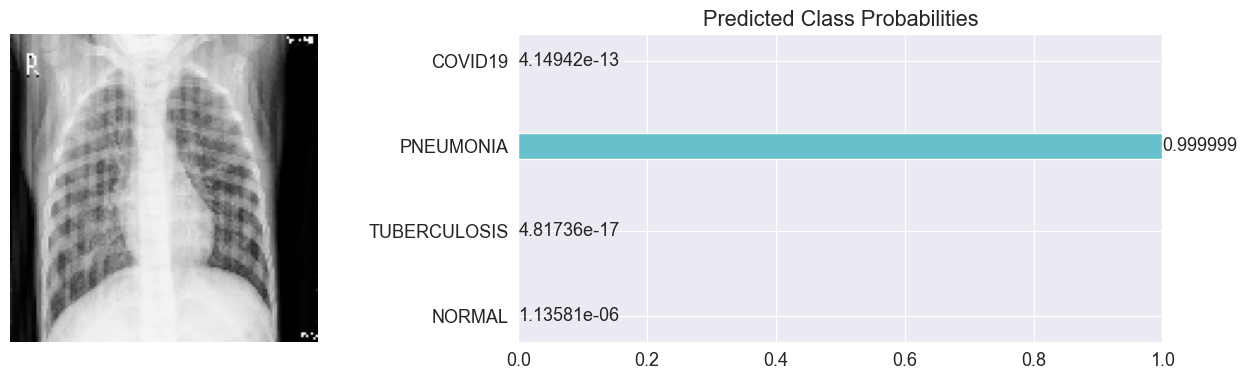

Actual   : PNEUMONIA
Predicted: PNEUMONIA
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 44ms/step


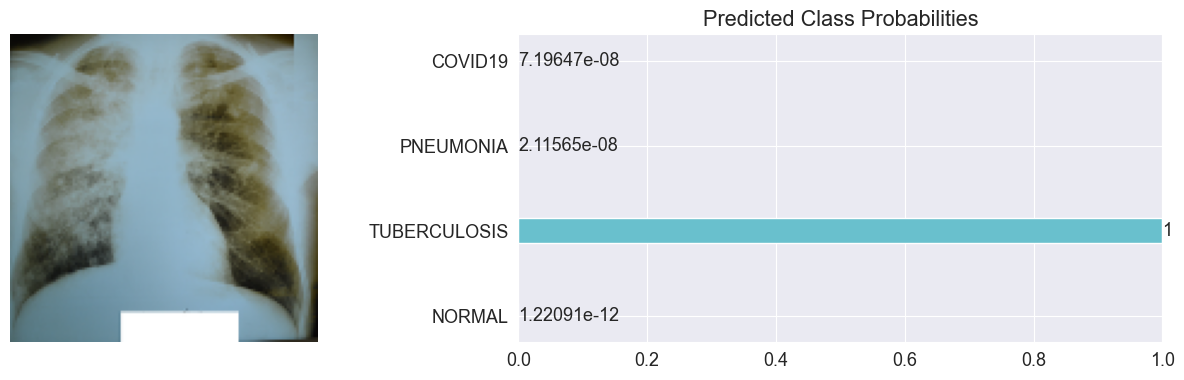

Actual   : TUBERCULOSIS
Predicted: TUBERCULOSIS
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 64ms/step


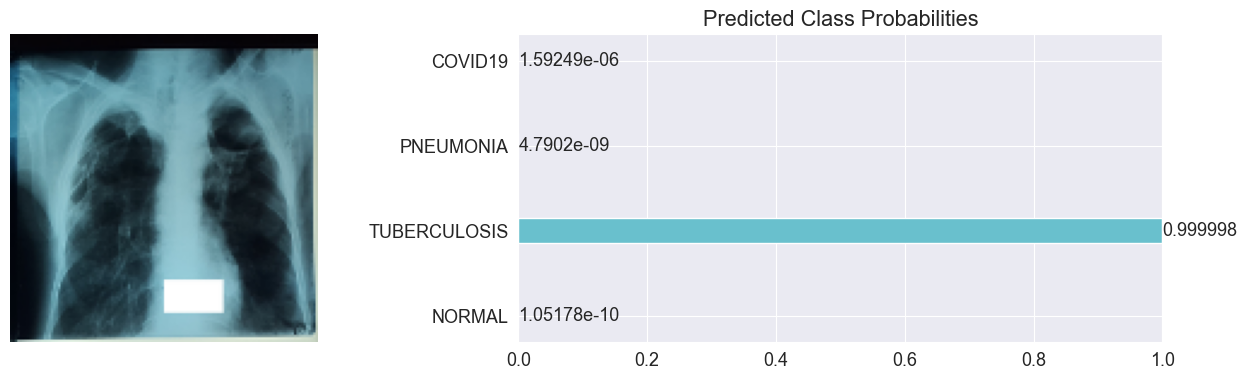

Actual   : TUBERCULOSIS
Predicted: TUBERCULOSIS
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 57ms/step


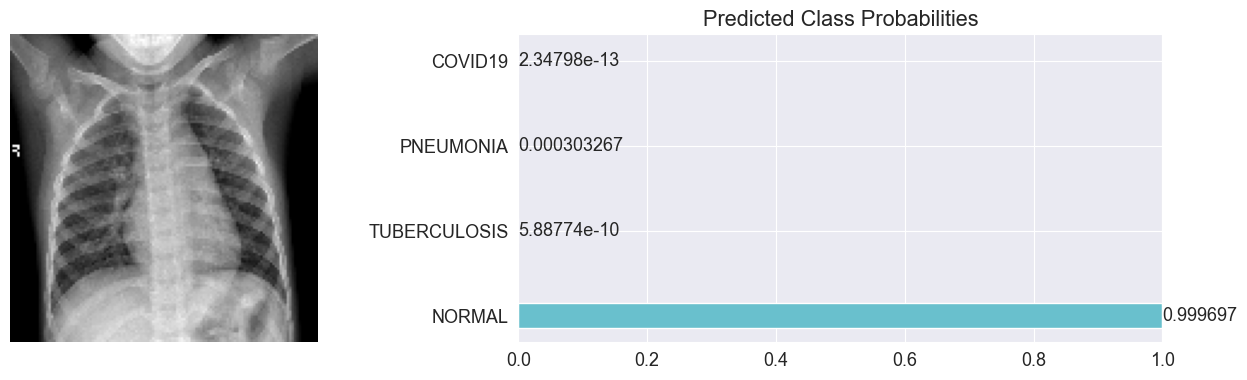

Actual   : NORMAL
Predicted: NORMAL
--------------------------------------------------------------------------------


1/1 [==============================] - 0s 38ms/step


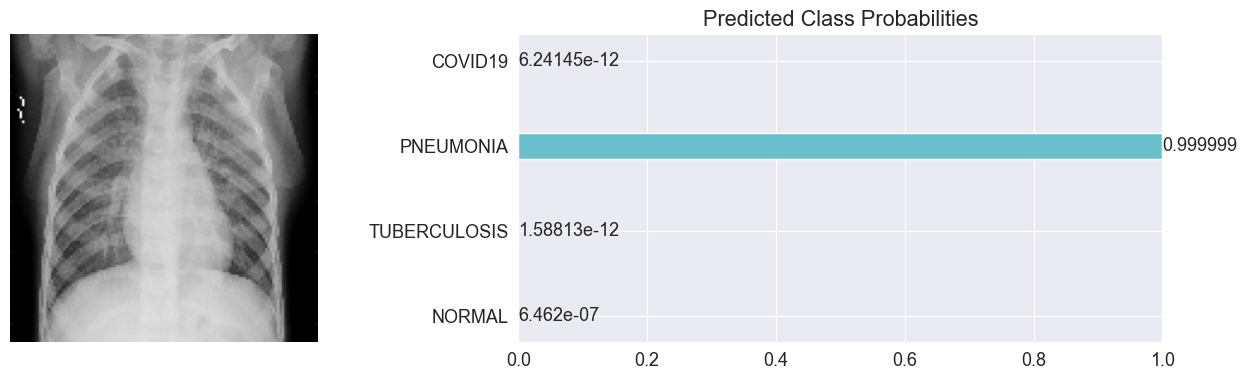

Actual   : PNEUMONIA
Predicted: PNEUMONIA
--------------------------------------------------------------------------------




In [ ]:
def predict(image, model):
    '''
    Input the image and model, this function outputs the prediction as:
        1. The class with the highest probability
        2. A dictionary containing each class with their corresponding probability
    '''
    image = np.array(image)
    image = image / image.max()
    image = image.reshape(-1, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE, 3)
    probabilities = model.predict(image).reshape(-1)
    pred = LABELS[np.argmax(probabilities)]
    return pred, {x: y for x, y in zip(LABELS, probabilities)}

INDICES = random.sample(list(df_test.index), 7)

for INDEX in INDICES:

    image = load_img(df_test.path[INDEX], target_size=(cfg.IMAGE_SIZE, cfg.IMAGE_SIZE))
    pred, probabilities = predict(image, model)

    x = list(probabilities.keys())
    y = list(probabilities.values())

    sns.set_style("darkgrid")
    fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={'width_ratios': [3, 4]})
    ax[0].imshow(image)
    ax[0].axis('off')

    bars = ax[1].barh(x, y, height=0.3, color=['#69c0cd', '#69c0cd', '#69c0cd', '#69c0cd'])
    ax[1].bar_label(bars)

    ax[1].set_title('Predicted Class Probabilities')
    plt.xlim([0, 1])
    plt.show()

    print('Actual   :', df_test.label[INDEX])
    print('Predicted:', pred)
    print('-' * 80)
    print('\n')

